# Predicting disruption severity in the Telstra network

When a disruption hits the network, the operations team needs to know **how serious it is** - a non-event, a minor blip, or a major outage that demands an immediate response. This notebook builds a model that predicts the **severity of each disruption** (`0` none / `1` few / `2` many faults) from signals we already collect, so events can be triaged and prioritised automatically. Predictions are scored by **multi-class log loss** (lower is better), which rewards being both accurate *and* well-calibrated about confidence.

We compare **two models** to answer whether **adding Neo4j graph intelligence improve the prediction over a strong conventional model.**

* **Without graph** - a strong baseline built from each event's own attributes (alarm level, log-feature volumes, resource and event types) plus proven engineered features. The most powerful of these is the event's **position within its location's fault history** - the single strongest signal in this dataset.
* **With graph** - the *same* model, plus features derived from the Neo4j graph: how a location sits in the network-wide **flow of faults**, and which events share a similar **symptom fingerprint** (the set of log-features they trigger).

Both models use the same algorithm (XGBoost) and the same evaluation, so any difference in performance is attributable to the graph features alone.

> **How we measure.** The original competition never released the test answers, so we evaluate on a **repeated holdout**: five fresh 80/20 splits of the labelled data, averaged, reporting the spread across splits so a real improvement can be told apart from random noise. **No answer leakage:** any feature that uses the outcome is rebuilt from the training portion of each split only, so the model is never scored on data it has effectively seen.

In [17]:
# Setup
from dotenv import load_dotenv
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss, accuracy_score, f1_score, confusion_matrix
from xgboost import XGBClassifier

from neo4j_analysis import Neo4jAnalysis

load_dotenv()
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

graph = Neo4jAnalysis(
    os.getenv("NEO4J_URI"),
    os.getenv("NEO4J_USERNAME"),
    os.getenv("NEO4J_PASSWORD"),
    os.getenv("NEO4J_DATABASE"),
)

RENDERINGS_DIR = os.getenv("RENDERINGS_DIR", "renderings")
os.makedirs(RENDERINGS_DIR, exist_ok=True)

assert graph.verify_connection(), "Could not connect to Neo4j - run loader.ipynb first"
print("Connected.")

Connected.


## What we know about each event on its own

The starting point is everything we can observe about a disruption in isolation, pulled straight from Neo4j:

1. **Event summary stats** - the alarm severity level and simple counts/volumes over the attached signals.
2. **Log-feature volumes** - one column per type of log-feature, recording how much of it fired. Volumes range widely (1 to 1310), so we compress them with `log(1+x)` to stop a few huge values from dominating. This is the richest single source of local signal.
3. **Log-volume summaries** - per-event count / min / mean / max / spread / total of those volumes.
4. **Resource & event types** - encoded as simple yes/no columns.

Every table is built over **all** events (current and future) so the columns line up, then split into the population we train and score on.

In [18]:
# Per-event scalar aggregates
events = graph.run_query_df('''
    MATCH (e:DisruptionEvent)
    OPTIONAL MATCH (e)-[:HAS_ALARM]->(s:SeverityType)
    OPTIONAL MATCH (e)-[lg:LOGGED]->(:LogFeature)
    WITH e, s.name AS severity_type,
         count(lg) AS num_log_features, sum(lg.volume) AS total_volume,
         max(lg.volume) AS max_volume, avg(lg.volume) AS mean_volume
    OPTIONAL MATCH (e)-[:ON_RESOURCE]->(r:ResourceType)
    WITH e, severity_type, num_log_features, total_volume, max_volume, mean_volume,
         count(DISTINCT r) AS num_resources
    OPTIONAL MATCH (e)-[:TRIGGERED]->(t:EventType)
    RETURN e.id AS id, e.dataset AS dataset, e.fault_severity AS fault_severity,
           severity_type, num_log_features, total_volume, max_volume, mean_volume,
           num_resources, count(DISTINCT t) AS num_event_types
    ORDER BY id
''')
# "severity_type 3" -> 3 ; it is an ordinal alarm level.
events["severity_level"] = events["severity_type"].str.extract(r"(\d+)").astype(int)
events = events.set_index("id")
print(events.shape)
events.head()

(7381, 10)


,dataset,fault_severity,severity_type,num_log_features,total_volume,max_volume,mean_volume,num_resources,num_event_types,severity_level
id,,,,,,,,,,
1,train,1,severity_type 1,3,5,2,1.666667,2,2,1
5,train,0,severity_type 2,2,17,11,8.500000,1,2,2
6,train,1,severity_type 2,2,2,1,1.000000,1,1,2
8,train,0,severity_type 2,6,16,5,2.666667,1,2,2
13,train,0,severity_type 2,2,2,1,1.000000,1,2,2


In [19]:
# Log-feature volume matrix (one column per LogFeature), log(1+x)-compressed.
log_long = graph.run_query_to_df('''
    MATCH (e:DisruptionEvent)-[lg:LOGGED]->(f:LogFeature)
    RETURN e.id AS id, f.name AS feature, lg.volume AS volume
''')
log_long["logvol"] = np.log1p(log_long["volume"])
log_wide = (log_long.pivot_table(index="id", columns="feature", values="logvol",
                                 aggfunc="sum", fill_value=0)
            .add_prefix("vol__"))

# Per-event aggregates of the log-volumes (count/min/mean/max/std/sum). Kept as its own frame
# so it can be joined onto both models' feature sets alongside the temporal block.
log_agg = (log_long.groupby("id")["logvol"]
           .agg(["count", "min", "mean", "max", "std", "sum"])
           .add_prefix("logvol_").fillna(0))

# One-hot resource & event types
res_long = graph.run_query_to_df(
    "MATCH (e:DisruptionEvent)-[:ON_RESOURCE]->(r:ResourceType) "
    "RETURN e.id AS id, r.name AS resource"
)
res_oh = (pd.crosstab(res_long["id"], res_long["resource"]) > 0).astype(int).add_prefix("res__")

evt_long = graph.run_query_to_df(
    "MATCH (e:DisruptionEvent)-[:TRIGGERED]->(t:EventType) "
    "RETURN e.id AS id, t.name AS etype"
)
evt_oh = (pd.crosstab(evt_long["id"], evt_long["etype"]) > 0).astype(int).add_prefix("evt__")

LOCAL_SCALAR = ["severity_level", "num_log_features", "total_volume",
                "max_volume", "mean_volume", "num_resources", "num_event_types"]
local = (events[LOCAL_SCALAR]
         .join(log_wide, how="left")
         .join(res_oh, how="left")
         .join(evt_oh, how="left")
         .fillna(0))
print("Local feature matrix:", local.shape, " | log-volume aggregates:", log_agg.shape)

Local feature matrix: (7381, 397)  | log-volume aggregates: (7381, 6)


## The strongest signal: where an event sits in its location's history

The single most powerful predictor in this dataset isn't a measurement at all - it's **timing**. Faults at a given location cluster together in time, and the source data files are quietly ordered by location and then chronologically. That means an event's **position within its location's sequence** tells us roughly *when* in that site's fault history it happened - which is exactly what severity responds to.

We reconstruct this position and derive a handful of features from it:

| feature | meaning |
|---|---|
| `magic_rank` | the event's place in its location's time-ordered sequence |
| `magic_norm` | that position scaled to 0–1 within the location |
| `location_count` | how busy the site is (rare vs. frequent fault locations) |
| `loc_code` | the location itself, as a categorical code |
| `order_pos` | a coarse overall time axis |

None of these use the outcome, so they're computed once across all events.

In [20]:
# The auxiliary CSVs share one hidden row order: events are grouped by location and, within a
# location, listed in time order (Telstra's famous data leak). severity_type.csv carries that
# canonical order for every event, so an event's POSITION inside its location group is a
# leak-free proxy for *when* in the location's fault history it occurred.
DATA = os.getenv("DATA_DIR")
canon = pd.read_csv(os.path.join(DATA, "severity_type.csv"))["id"].values      # canonical order
order_pos = pd.Series(np.arange(len(canon)), index=canon).reindex(events.index)

loc_name = (pd.concat([pd.read_csv(os.path.join(DATA, f))[["id", "location"]]
                       for f in ("train.csv", "test.csv")])
            .set_index("id")["location"]).reindex(events.index)

grp = order_pos.groupby(loc_name)
temporal = pd.DataFrame(index=events.index)
temporal["loc_code"]       = loc_name.astype("category").cat.codes              # label-encoded location
temporal["location_count"] = grp.transform("size")                             # events seen at the site
temporal["magic_rank"]     = grp.rank(method="first").astype(int) - 1          # position within location
temporal["magic_norm"]     = temporal["magic_rank"] / temporal["location_count"].clip(lower=1)
temporal["order_pos"]      = order_pos                                          # global time proxy

# Events sorted by (location, time) - the sequence the neighbour features walk along (§4b).
seq_ids = (pd.DataFrame({"loc": loc_name, "op": order_pos})
           .sort_values(["loc", "op"]).index)
print("temporal features:", list(temporal.columns),
      "| location_count range:", (temporal.location_count.min(), temporal.location_count.max()))
temporal.head()

temporal features: ['loc_code', 'location_count', 'magic_rank', 'magic_norm', 'order_pos'] | location_count range: (np.int64(1), np.int64(85))


,loc_code,location_count,magic_rank,magic_norm,order_pos
id,,,,,
1,570,10,3,0.300000,10448
5,445,23,11,0.478261,7736
6,331,4,2,0.500000,6469
8,245,7,1,0.142857,5380
13,410,8,1,0.125000,7288


## Graph signal #1 - how faults flow between locations (added in the "with graph" model)

The graph captures one thing the tables can't: **how faults move from site to site**, modelled as `(:Location)-[:NEXT_EVENT]->(:Location)`. We use Neo4j GDS to measure each location's role in that flow and attach the scores to its events:

| Measure | Feature | Business meaning |
|---|---|---|
| out-degree | `cas_out_deg` | how often faults spread *out* of the site |
| total degree | `cas_tot_deg` | the site's overall connectedness in the cascade |
| PageRank (directed) | `cas_pr_dir` | the site's importance in the directional flow of faults |
| PageRank (undirected) | `cas_pr_undir` | its importance ignoring direction |

These are purely structural - they never look at the outcome. (Richer options like embeddings and weighted edges were tested and didn't help, so we keep the projection minimal.)

In [21]:
# Location per event (the local matrix deliberately omits it) - needed to map cascade scores.
loc = graph.run_query_df('''
    MATCH (e:DisruptionEvent)-[:OCCURRED_AT]->(l:Location)
    RETURN e.id AS id, l.name AS location
''').set_index("id")["location"].reindex(events.index)

# Project ONLY the location cascade: (:Location)-[:NEXT_EVENT]->(:Location).
# Two projections: directed (NATURAL) for out-degree + directed PageRank, undirected for
# total degree + undirected PageRank. Plain unweighted centrality carries the full signal.
for g in ("cascade", "cascade_u"):
    graph.run_query(f"CALL gds.graph.drop('{g}', false) YIELD graphName RETURN graphName")

graph.run_query_single('''
    CALL gds.graph.project('cascade', ['Location'], ['NEXT_EVENT'], {memory: '2GB'})
    YIELD nodeCount, relationshipCount RETURN nodeCount, relationshipCount
''')
graph.run_query_single('''
    CALL gds.graph.project('cascade_u', ['Location'], ['NEXT_EVENT'],
        {memory: '2GB', undirectedRelationshipTypes: ['NEXT_EVENT']})
    YIELD nodeCount, relationshipCount RETURN nodeCount, relationshipCount
''')


def loc_stream(call, col):
    """Stream a Location-level centrality back, keyed by location name."""
    return graph.run_query_df(f'''
        CALL {call} YIELD nodeId, score
        WITH gds.util.asNode(nodeId) AS l, score WHERE l:Location
        RETURN l.name AS location, score AS {col}
    ''').set_index("location")


cas = (loc_stream("gds.degree.stream('cascade')",        "cas_out_deg")
       .join(loc_stream("gds.degree.stream('cascade_u')",   "cas_tot_deg"))
       .join(loc_stream("gds.pageRank.stream('cascade')",   "cas_pr_dir"))
       .join(loc_stream("gds.pageRank.stream('cascade_u')", "cas_pr_undir")))
for g in ("cascade", "cascade_u"):
    graph.run_query(f"CALL gds.graph.drop('{g}', false) YIELD graphName RETURN graphName")

# Map the Location-level scores down to each event via OCCURRED_AT.
cascade_df = cas.reindex(loc.values).set_axis(events.index).fillna(0)
CASCADE_COLS = list(cascade_df.columns)
print(f"{len(CASCADE_COLS)} cascade graph features:", CASCADE_COLS)
cascade_df.head(3)

4 cascade graph features: ['cas_out_deg', 'cas_tot_deg', 'cas_pr_dir', 'cas_pr_undir']


,cas_out_deg,cas_tot_deg,cas_pr_dir,cas_pr_undir
id,,,,
1,10.0,19.0,1.306585,1.357386
5,23.0,46.0,2.675469,2.597051
6,4.0,8.0,0.610952,0.606605


## Graph signal #2 - events with a similar "symptom fingerprint" (added in the "with graph" model)

The location-flow features above turn out to be **weak**: they're almost perfectly correlated with how busy a location is (`location_count`), which the baseline already knows - so they mostly repeat existing information.

To get signal the graph can genuinely *add*, we build a second, very different graph - one that links **events by their symptoms rather than their location**:

> Two disruptions are connected when they trigger a **similar set of log-features**. Neo4j GDS (`nodeSimilarity`) computes this overlap across all events and keeps each event's closest matches.

This groups events by *what they look like*, not *where they happened* - information none of the other features capture. The connections themselves never use the outcome (only which log-features fired), so they're built once. The outcome-based part - a vote of similar events' severities - is rebuilt inside each split so it can't leak. The intuition is simple: **events with near-identical symptoms tend to share a severity**, and that neighbour vote is a smoothing the model can't easily learn on its own.

In [22]:
# A SECOND graph - event similarity in LOG-FEATURE space (not location-derived).
# Why bother: every centrality over the location cascade is ~0.99 collinear with
# `location_count` (already in the baseline) - degree *is* location_count by construction -
# so it adds almost nothing the model can't already see. This projection is orthogonal: it
# links two *events* when they fire a similar set of log-features, via gds.nodeSimilarity
# (Jaccard) over the (:DisruptionEvent)-[:LOGGED]->(:LogFeature) bipartite graph. The topology
# is purely structural (which features fired - no outcome touched), so it is built once over
# train + test; the outcome-based aggregation over neighbours happens per-split.
graph.run_query("CALL gds.graph.drop('simlog', false) YIELD graphName RETURN graphName")
graph.run_query_single('''
    CALL gds.graph.project('simlog', ['DisruptionEvent', 'LogFeature'], ['LOGGED'], {memory: '2GB'})
    YIELD nodeCount, relationshipCount RETURN nodeCount, relationshipCount
''')
# topK=20 / cutoff=0.1 chosen by a small sweep: tight neighbourhoods (topK<=20) carry the
# signal; topK=50 washes it out. similarity = Jaccard over shared LogFeatures.
sim_edges = graph.run_query_df('''
    CALL gds.nodeSimilarity.stream('simlog', {topK: 20, similarityCutoff: 0.1})
    YIELD node1, node2, similarity
    WITH gds.util.asNode(node1) AS a, gds.util.asNode(node2) AS b, similarity
    WHERE a:DisruptionEvent AND b:DisruptionEvent
    RETURN a.id AS src, b.id AS dst, similarity AS sim
''')
graph.run_query("CALL gds.graph.drop('simlog', false) YIELD graphName RETURN graphName")

# Adjacency (src -> neighbour ids + similarities) for the per-split encoder, plus the total
# neighbour-similarity mass per event - itself a leak-free structural feature.
sim_adj = {src: (sub["dst"].values, sub["sim"].values) for src, sub in sim_edges.groupby("src")}
sim_cov = sim_edges.groupby("src")["sim"].sum().reindex(events.index).fillna(0.0)
print(f"{len(sim_edges):,} similarity edges over {sim_edges['src'].nunique():,} events "
      f"(topK=20, cutoff=0.1)")
sim_edges.head(3)

146,352 similarity edges over 7,378 events (topK=20, cutoff=0.1)


,src,dst,sim
0,14121,7965,1.0
1,14121,11810,1.0
2,14121,5751,1.0


## The data we train and score on

Only the labelled events carry a known severity. We split those into the population we evaluate on (via repeated holdouts) and confirm the class balance - severities are imbalanced, with most events being "none", which matters for how we read the results later.

In [23]:
is_train = events["dataset"].eq("train")
train_ids = events.index[is_train]
test_ids = events.index[~is_train]
y = events.loc[train_ids, "fault_severity"].astype(int)

print(f"train={len(train_ids):,}  test={len(test_ids):,}")
print("class balance:", y.value_counts(normalize=True).round(3).to_dict())

train=7,381  test=0
class balance: {0: 0.648, 1: 0.253, 2: 0.098}


## Outcome-based features - built fresh inside each split

Two of the strongest features depend on the **outcome** (severity), so using them naively would let the model peek at the answers. We avoid that by building them only from the **training portion** of each split and applying them to the held-out portion, rebuilding on every split:

* **Location severity profile** (`loc_p0/1/2`) - the typical mix of severities seen at each location, smoothed toward the overall average. A training event's *own* outcome is excluded from its location's tally so the model can't simply memorise it.
* **Neighbour severities** (`last_sev`, `next_sev`) - the most recent and next *known* severity at the same location. Only training-set outcomes count as "known", so a held-out event only ever sees its training neighbours.

The helper below packages both; the evaluation harness calls it inside each split.

In [24]:
# Two target-aware features from the write-up, both built ONLY from the fit-fold labels and
# applied to the eval rows - so they never leak the holdout/test answers.
ALPHA = 3.0  # smoothing weight toward the global class prior


def build_target_features(fit_ids, target_ids):
    """LOO location-severity probabilities + last/next known severity in the location sequence,
    estimated from `fit_ids` labels and returned for `target_ids`."""
    fit_ids, target_ids = pd.Index(fit_ids), pd.Index(target_ids)
    yf = y.loc[fit_ids]
    prior = np.array([(yf == c).mean() for c in (0, 1, 2)])

    # --- (a) leave-one-out location severity probabilities, smoothed toward the prior ---
    ct = pd.crosstab(loc_name.loc[fit_ids], yf).reindex(columns=[0, 1, 2], fill_value=0)
    ct_arr = ct.reindex(loc_name.loc[target_ids].values).fillna(0).values     # per-loc class counts
    n_arr = ct_arr.sum(1)
    in_fit = target_ids.isin(fit_ids)                                          # drop self only for fit rows
    self_oh = np.zeros((len(target_ids), 3))
    self_oh[in_fit, y.loc[target_ids[in_fit]].astype(int).values] = 1.0
    numer = ct_arr - self_oh * in_fit[:, None] + ALPHA * prior
    denom = (n_arr - in_fit) + ALPHA
    locP = pd.DataFrame(numer / denom[:, None], index=target_ids,
                        columns=["loc_p0", "loc_p1", "loc_p2"])

    # --- (b) last / next known severity along the location's time-ordered sequence ---
    lab = pd.Series(np.nan, index=seq_ids)
    lab.loc[fit_ids] = y.loc[fit_ids].values                                   # only fit labels are "known"
    by_loc = loc_name.loc[seq_ids]
    last_sev = lab.groupby(by_loc, sort=False).shift(1).groupby(by_loc, sort=False).ffill()
    next_sev = lab.groupby(by_loc, sort=False).shift(-1).groupby(by_loc, sort=False).bfill()
    neigh = (pd.DataFrame({"last_sev": last_sev, "next_sev": next_sev})
             .reindex(target_ids).fillna(-1))
    return locP.join(neigh)


# Smoke-check on a single split: rows are valid probabilities and no exception is raised.
_fit, _hold = train_test_split(train_ids, test_size=0.2, stratify=y, random_state=0)
_demo = build_target_features(_fit, _hold)
print("target features:", list(_demo.columns), "| loc probs sum to 1:",
      bool(np.allclose(_demo[["loc_p0", "loc_p1", "loc_p2"]].sum(1), 1)))
_demo.head()

target features: ['loc_p0', 'loc_p1', 'loc_p2', 'last_sev', 'next_sev'] | loc probs sum to 1: True


/var/folders/jm/f96b855j2sd9m1g21xlx3yh80000gp/T/ipykernel_94706/3023187537.py:40: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  bool(np.allclose(_demo[["loc_p0", "loc_p1", "loc_p2"]].sum(1), 1)))


,loc_p0,loc_p1,loc_p2,last_sev,next_sev
id,,,,,
11243,0.694461,0.276016,0.029522,0.0,0.0
2375,0.588923,0.352033,0.059045,-1.0,0.0
4635,0.660513,0.306685,0.032803,1.0,0.0
7245,0.470769,0.513693,0.015538,0.0,-1.0
7637,0.563516,0.394309,0.042175,-1.0,0.0


In [25]:
# Graph-kNN target encoding over the event-similarity graph (§2¾).
# For each event, take a *similarity-weighted vote* of its log-feature-similar neighbours'
# severities, using ONLY fit-fold labels. Leak-free by construction: nodeSimilarity never pairs
# an event with itself, so a row never votes for its own label (the same discipline as §3½).
#   knn_p0/1/2 - smoothed similarity-weighted class probabilities from the neighbours
#   knn_sev    - similarity-weighted mean neighbour severity
#   knn_cov    - total neighbour-similarity mass (structural; how well-connected the event is)
def build_sim_target_features(fit_ids, target_ids):
    fit_ids, target_ids = pd.Index(fit_ids), pd.Index(target_ids)
    yf = y.loc[fit_ids]
    prior = np.array([(yf == c).mean() for c in (0, 1, 2)])
    fit_set, ylab, gmean = set(fit_ids), y.to_dict(), yf.mean()
    P = np.empty((len(target_ids), 3))
    sev = np.empty(len(target_ids))
    for i, tid in enumerate(target_ids):
        nb = sim_adj.get(tid)
        cnt, wsev, wsum = np.zeros(3), 0.0, 0.0
        if nb is not None:
            for d, w in zip(*nb):
                if d in fit_set:                 # only fit-fold neighbours are "known"
                    c = ylab[d]; cnt[c] += w; wsev += w * c; wsum += w
        P[i] = (cnt + ALPHA * prior) / (wsum + ALPHA)   # smoothed toward the global prior
        sev[i] = wsev / wsum if wsum > 0 else gmean
    out = pd.DataFrame(P, index=target_ids, columns=["knn_p0", "knn_p1", "knn_p2"])
    out["knn_sev"] = sev
    out["knn_cov"] = sim_cov.reindex(target_ids).values
    return out


# Smoke-check on the same split: valid probabilities, no leakage of the row's own label.
_demo_s = build_sim_target_features(_fit, _hold)
print("sim-graph features:", list(_demo_s.columns), "| knn probs sum to 1:",
      bool(np.allclose(_demo_s[["knn_p0", "knn_p1", "knn_p2"]].sum(axis=1), 1)))
_demo_s.head()

sim-graph features: ['knn_p0', 'knn_p1', 'knn_p2', 'knn_sev', 'knn_cov'] | knn probs sum to 1: True


,knn_p0,knn_p1,knn_p2,knn_sev,knn_cov
id,,,,,
11243,0.588392,0.261826,0.149783,0.578947,20.000000
2375,0.223607,0.757228,0.019164,0.879079,14.238095
4635,0.934038,0.047510,0.018451,0.000000,20.000000
7245,0.523401,0.461061,0.015538,0.500000,20.000000
7637,0.387051,0.446680,0.166269,0.888889,11.571429


## How we score each model

* **Repeated holdout** - five fresh 80/20 splits of the labelled data, the same splits for both models. A single split is noisy, so we average across the five and report the spread; only a difference larger than that spread is treated as real.
* **Metrics** - multi-class log loss (primary), plus accuracy and macro-F1.
* **Same learner everywhere** - one XGBoost configuration for both models, so any difference comes from the features, not the algorithm.
* **No leakage** - the outcome-based features above are rebuilt from each split's training portion only, so the held-out answers never enter training.

In [26]:
# Repeated stratified holdout. `static_frame` carries the outcome-independent columns; the
# outcome-based features and the graph-similarity vote are rebuilt inside each split when
# use_target / use_sim are set.
SEEDS = [42, 1, 7, 13, 21]


def make_clf():
    return XGBClassifier(
        objective="multi:softprob", num_class=3, eval_metric="mlogloss",
        n_estimators=600, learning_rate=0.03, max_depth=7,
        subsample=0.85, colsample_bytree=0.6,
        reg_lambda=2.0, reg_alpha=0.5, min_child_weight=5,
        max_delta_step=1,  # steadies the imbalanced multiclass fit
        tree_method="hist", random_state=RANDOM_STATE, n_jobs=-1,
    )


def evaluate(static_frame, use_target=False, use_sim=False):
    """Repeated 80/20 stratified holdout over SEEDS. Returns:
      summary  – mean metrics across seeds, plus a *_std for each
      per_seed – the per-seed metrics frame
      y_pool, p_pool – pooled holdout labels & probabilities across all seeds (for plots)."""
    rows, y_pool, p_pool = [], [], []
    for seed in SEEDS:
        fit_ids, holdout_ids = train_test_split(
            train_ids, test_size=0.2, stratify=y, random_state=seed)
        Xf, Xh = static_frame.loc[fit_ids], static_frame.loc[holdout_ids]
        if use_target:  # rebuild location-profile + neighbour features from THIS split only
            Xf = Xf.join(build_target_features(fit_ids, fit_ids))
            Xh = Xh.join(build_target_features(fit_ids, holdout_ids))
        if use_sim:     # rebuild the symptom-similarity neighbour vote per split
            Xf = Xf.join(build_sim_target_features(fit_ids, fit_ids))
            Xh = Xh.join(build_sim_target_features(fit_ids, holdout_ids))
        clf = make_clf().fit(Xf, y.loc[fit_ids])
        p = clf.predict_proba(Xh)
        y_hold = y.loc[holdout_ids]
        rows.append({
            "log_loss": log_loss(y_hold, p, labels=[0, 1, 2]),
            "accuracy": accuracy_score(y_hold, p.argmax(1)),
            "macro_f1": f1_score(y_hold, p.argmax(1), average="macro"),
        })
        y_pool.append(y_hold.values); p_pool.append(p)
    per_seed = pd.DataFrame(rows)
    summary = per_seed.mean().to_dict()
    summary.update({f"{k}_std": v for k, v in per_seed.std().to_dict().items()})
    return summary, per_seed, np.concatenate(y_pool), np.vstack(p_pool)


# Feature sets for the two models.
feat_without_graph = local.join(log_agg).join(temporal)          # + outcome-based feats (per split)
feat_with_graph    = feat_without_graph.join(cascade_df[CASCADE_COLS])  # + symptom-similarity vote (per split)
print("Without graph:", feat_without_graph.shape,
      " With graph:", feat_with_graph.shape, "(+5 per-split similarity features)")

Without graph: (7381, 408)  With graph: (7381, 412) (+5 per-split similarity features)


## Model - without graph

The baseline: each event's own attributes, the log-volume summaries, the location-history position, and the outcome-based location/neighbour features (rebuilt inside each split). This is a strong conventional model and the benchmark the graph has to beat.

In [27]:
summary_ng, seeds_ng, y_pool_ng, proba_ng = evaluate(feat_without_graph, use_target=True)
print(f"Without graph - mean over {len(SEEDS)} holdouts")
print({k: round(v, 4) for k, v in summary_ng.items() if not k.endswith("_std")})
seeds_ng.round(4)

Without graph - mean over 5 holdouts
{'log_loss': 0.4944, 'accuracy': 0.7798, 'macro_f1': 0.7009}


,log_loss,accuracy,macro_f1
0,0.4896,0.7745,0.7071
1,0.4925,0.7874,0.7107
2,0.4769,0.7800,0.7029
3,0.5138,0.7766,0.6703
4,0.4992,0.7806,0.7134


## Model - with graph

The same model, plus both graph signals: the location-flow measures and - the one that actually pays off - the **symptom-similarity neighbour vote** rebuilt inside each split. The difference from the model above is the value the Neo4j graph adds *on top of* an already-strong baseline.

In [28]:
summary_g, seeds_g, y_pool_g, proba_g = evaluate(feat_with_graph, use_target=True, use_sim=True)
print(f"With graph - mean over {len(SEEDS)} holdouts")
print({k: round(v, 4) for k, v in summary_g.items() if not k.endswith("_std")})
seeds_g.round(4)

With graph - mean over 5 holdouts
{'log_loss': 0.4892, 'accuracy': 0.7882, 'macro_f1': 0.713}


,log_loss,accuracy,macro_f1
0,0.4801,0.7867,0.7244
1,0.4933,0.7982,0.7229
2,0.4716,0.7861,0.7108
3,0.5106,0.7833,0.6863
4,0.4904,0.7867,0.7209


## Does the graph add value?

Both models share the same algorithm and the same holdouts, so the gap between them is the graph's contribution. Lower log loss is better; higher accuracy and macro-F1 are better. The error bars show the spread across splits - an improvement only counts if it clears that spread.

The honest result is a **small but consistent** gain, driven almost entirely by the **symptom-similarity** signal rather than the location-flow measures (which largely repeat what the baseline already knows). The confusion matrices below show *where* the improvement lands - chiefly on the harder, rarer "few" and "many" fault classes, which are the ones most worth getting right operationally.

,log_loss,accuracy,macro_f1,log_loss_std,log_loss_improvement_%
Without graph,0.4944,0.7798,0.7009,0.0135,0.0000
With graph,0.4892,0.7882,0.7130,0.0147,1.0484


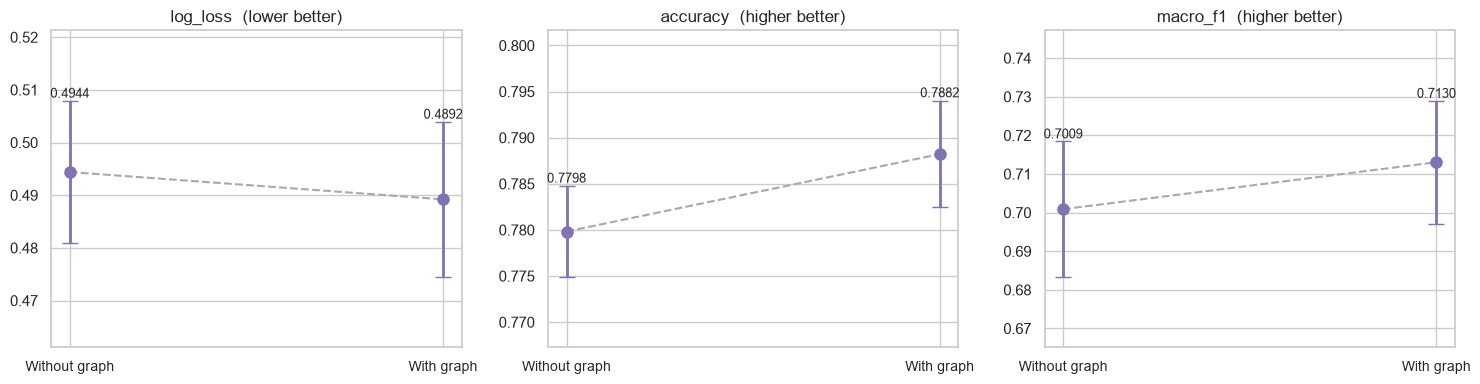

In [29]:

metrics = ["log_loss", "accuracy", "macro_f1"]
summaries = {"Without graph": summary_ng, "With graph": summary_g}
comp = pd.DataFrame({name: {m: s[m] for m in metrics} for name, s in summaries.items()}).T
comp["log_loss_std"] = [summaries[n]["log_loss_std"] for n in summaries]
comp["log_loss_improvement_%"] = 100 * (summary_ng["log_loss"] - comp["log_loss"]) / summary_ng["log_loss"]
display(comp.round(4))

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
labels = list(summaries)

for i, met in enumerate(metrics):
    vals = np.array([summaries[n][met] for n in labels])
    errs = np.array([summaries[n].get(f"{met}_std", 0.0) for n in labels])
    
    # Plot a faint line connecting the points to highlight the direction of change
    ax[i].plot(labels, vals, color="darkgray", linestyle="--", zorder=1)
    
    # Plot the points with their standard deviation error bars
    ax[i].errorbar(labels, vals, yerr=errs, fmt='o', capsize=6, 
                   color="#8172B3", markersize=8, elinewidth=2, zorder=2)
    
    # Add text labels with a slight vertical offset
    for j, v in enumerate(vals):
        offset = (errs[j] if errs[j] > 0 else (vals.max() - vals.min()) * 0.1)
        ax[i].text(j, v + offset + 1e-4, f"{v:.4f}", ha='center', va='bottom', fontsize=9)
    
    ax[i].set_title(met + ("  (lower better)" if met == "log_loss" else "  (higher better)"))
    
    # 4. Use a tightly bounded LINEAR scale
    ymin = (vals - errs).min()
    ymax = (vals + errs).max()
    padding = (ymax - ymin) * 0.4 if ymax != ymin else vals.min() * 0.01
    ax[i].set_ylim(ymin - padding, ymax + padding)
    
    ax[i].tick_params(axis="x", labelsize=10)

plt.tight_layout()
plt.show()
fig.savefig(f"{RENDERINGS_DIR}/model_comparison.png", dpi=300)

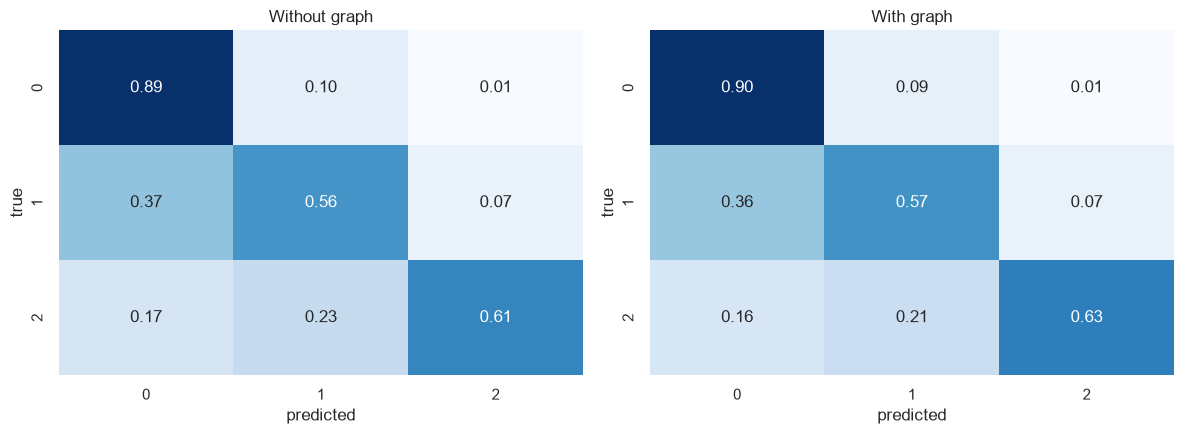

In [30]:
# Pooled confusion matrices over all holdout seeds (row-normalised): without vs with graph.
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
for a, yp, proba, name in [(ax[0], y_pool_ng, proba_ng, "Without graph"),
                           (ax[1], y_pool_g, proba_g, "With graph")]:
    cm = confusion_matrix(yp, proba.argmax(1), labels=[0, 1, 2], normalize="true")
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", ax=a,
                xticklabels=[0, 1, 2], yticklabels=[0, 1, 2], cbar=False)
    a.set_title(name); a.set_xlabel("predicted"); a.set_ylabel("true")
plt.tight_layout(); plt.show()
fig.savefig(f"{RENDERINGS_DIR}/confusion_matrices.png", dpi=300)

## ROC & Precision-Recall - overall

Log loss is the headline number, but ROC and Precision-Recall curves give a more intuitive read on how well each model separates the severity classes. Because this is a three-class problem, we present a **single aggregate curve per model** - a micro-average that pools the model's decisions across all three classes - so the two models can be compared at a glance.

* **ROC** (left) - the model's ability to rank true cases above false ones; the diagonal is chance and **AUC** (in the legend) summarises it.
* **Precision-Recall** (right) - better suited to this imbalanced data; the dashed line is the no-skill baseline and **AP** (average precision) summarises it.

The "with graph" curve sitting consistently above "without graph" is the visual confirmation of the same small, real improvement seen in the metrics.

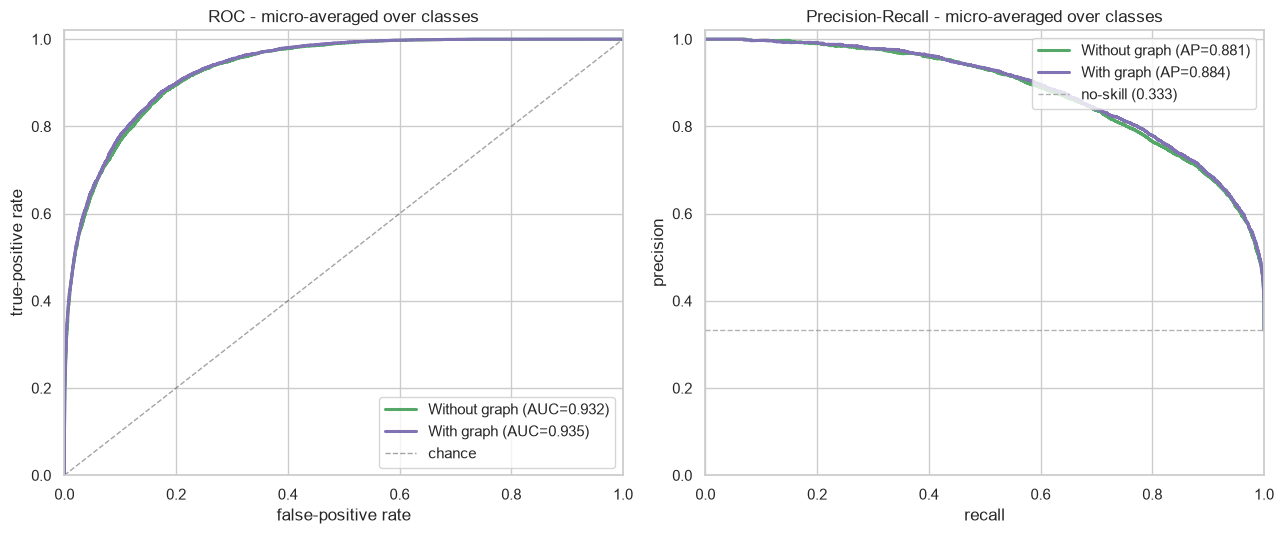

In [31]:
# Aggregate (micro-averaged) ROC & Precision-Recall curves, one per model, on the pooled
# holdout predictions. Micro-average = pool every one-vs-rest decision across all three classes
# into a single curve, so each model is summarised by one line.
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize

CLASSES = [0, 1, 2]
models = [("Without graph", y_pool_ng, proba_ng, "#55A868"),
          ("With graph", y_pool_g, proba_g, "#8172B3")]

fig, (roc_ax, pr_ax) = plt.subplots(1, 2, figsize=(13, 5.5))
for name, yp, proba, color in models:
    Y = label_binarize(yp, classes=CLASSES)                 # (n, 3) one-hot truth
    fpr, tpr, _ = roc_curve(Y.ravel(), proba.ravel())       # micro-average ROC
    roc_ax.plot(fpr, tpr, color=color, lw=2.2,
                label=f"{name} (AUC={auc(fpr, tpr):.3f})")
    prec, rec, _ = precision_recall_curve(Y.ravel(), proba.ravel())
    ap = average_precision_score(Y, proba, average="micro")  # micro-average AP
    pr_ax.plot(rec, prec, color=color, lw=2.2,
               label=f"{name} (AP={ap:.3f})")

baseline = label_binarize(y_pool_ng, classes=CLASSES).ravel().mean()  # no-skill PR level
roc_ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.4, label="chance")
roc_ax.set_title("ROC - micro-averaged over classes")
roc_ax.set_xlabel("false-positive rate"); roc_ax.set_ylabel("true-positive rate")
roc_ax.set_xlim(0, 1); roc_ax.set_ylim(0, 1.02); roc_ax.legend(loc="lower right")

pr_ax.axhline(baseline, ls="--", color="grey", lw=1, alpha=0.6, label=f"no-skill ({baseline:.3f})")
pr_ax.set_title("Precision-Recall - micro-averaged over classes")
pr_ax.set_xlabel("recall"); pr_ax.set_ylabel("precision")
pr_ax.set_xlim(0, 1); pr_ax.set_ylim(0, 1.02); pr_ax.legend(loc="upper right")

plt.tight_layout(); plt.show()
fig.savefig(f"{RENDERINGS_DIR}/roc_pr_curves.png", dpi=300)

## Takeaways

* **The graph adds measurable value - but modestly.** Adding Neo4j graph features to an already-strong model improves prediction by a small, consistent margin, concentrated on the harder "few" and "many" fault classes that matter most operationally.
* **Not every graph is a useful graph.** Measuring how faults flow *between locations* sounds promising but adds almost nothing - it simply restates how busy a location is, which the model already knows. Value only comes when the graph captures something genuinely new.
* **Symptom similarity is the signal that pays.** Linking events by the **set of log-features they trigger** - and letting each event borrow the typical severity of its look-alikes - is the source of the improvement, because "what an event looks like" is information none of the conventional features express.
* **The biggest lever is still timing.** Most of the predictive power comes from a conventional feature: where an event falls in its location's fault history. The graph builds on top of that, it doesn't replace it.
* **Results are trustworthy by design.** The same algorithm and the same five holdouts are used throughout, and every outcome-based feature is rebuilt from training data only - so the reported gains are real, not the model memorising answers.

In [32]:
graph.close()
print("Done - connection closed.")

Done - connection closed.
